In [95]:
# Standard libraries
import sys
import os
import ast
import time
from pathlib import Path
import functools
import pickle
import itertools
from itertools import chain, combinations
import concurrent
import random
random.seed(0)

# Third-party libraries
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx

# Local libraries
from conf import config
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from nomad import shortest_path as sp
from nomad import supernetwork as sn
from nomad import utils
from conf import config

# Code to read in the supernetwork as an object
graphs_folder = Path().parent.absolute().resolve() / 'graphs'
print(graphs_folder)
with open(graphs_folder / 'graph_sn.pkl', 'rb') as inp:
    G_sn = pickle.load(inp)

/home/lgraff/Documents/nomad/project3-network_opt/graphs


In [96]:
# Match each microtransit edge to its service zone
from nomad import costs

df_G = costs.edges.nx_to_df(G_sn)

df_mt = df_G[df_G['mode_type'] == 'mt'][['source','target','mode_type','zones']]
df_mt['zones'] = df_mt['zones'].astype(str).apply(ast.literal_eval).apply(tuple)

unique_zones = df_mt['zones'].unique()
print(unique_zones)

[(3,) (0,) (0, 4) (4,) (1,) (2,)]


In [97]:
# Set cost sensitivities
BETAS = {
    'tt': 10/3600,
    'rel': 10/3600,
    'x': 1,
    'risk': 20,
    'disc': 0
        }

# Set timestamp
hour = 8, 
minute = 0

# Get edge and node cost by ege
df_edge_cost_sn, df_node_cost_sn = sp.static.get_graph_costs(G_sn, BETAS, hour, minute, config)

# Group by 'edge' and aggregate with minimum 'gtc'. Since we initially sort the df, we are sure that the first mode_type we see is the one associated with the min_gtc
df_edge_cost_sn.sort_values(by=['source','target','GTC'], inplace=True)  
df_edge_cost_sn = df_edge_cost_sn.groupby(['source','target']).agg({'mode_type': 'first', 'GTC': 'min'}).reset_index()
df_edge_cost_sn.mode_type.unique()

# Remove org-org and dst-dst edges. TODO: move this to where we build microtransit edges in nomad/supernetwork.py
df_edge_cost_sn = df_edge_cost_sn[~((df_edge_cost_sn['source'].str.startswith('org')) & (df_edge_cost_sn['target'].str.startswith('org')))]
df_edge_cost_sn = df_edge_cost_sn[~((df_edge_cost_sn['source'].str.startswith('dst')) & (df_edge_cost_sn['target'].str.startswith('dst')))]

In [98]:
df = nx.to_pandas_edgelist(G_sn.graph)

df[(df['source'] == 'org0103022') & (df['target'] == 'org1401003') ]
#df_edge_cost_sn[df_edge_cost_sn['mode_type'] == 'mt']

,source,target,geometry,mode_type,etype,crash_count,bikeway_type,frc,speed_lim,st_name,bikelane_id,oneway,id,length_m,95_length_m,avg_tt_sec,zones,pred_crash,tot_inj_sum


In [99]:
def get_zonal_edges(df_mt, zoneID):
    """Get edges associated with a specific zone ID in the df_mt DataFrame.
    Returns:
    list: List of edges associated with the specified zone ID.
    """
    df_mt_zone = df_mt[df_mt['zones'].apply(lambda x: zoneID in x)]
    edges = list(zip(df_mt_zone['source'], df_mt_zone['target'])) 
    return edges

def get_bikeshare_edges(df_edge_cost, unselected_bikeshare_list):
    # Filter rows where either 'source' or 'target' matches any node in the unselected_bikeshare_list
    edges = df_edge_cost[(df_edge_cost['source'].isin(unselected_bikeshare_list)) | (df_edge_cost['target'].isin(unselected_bikeshare_list))]
                    
    # Convert to a list of tuples (source, target)
    edges = list(zip(edges['source'], edges['target']))
    return edges

def remove_unselected_investments(df_edge_cost, df_mt, unselected_zoneID_list, unselected_bikeshare_list):
    """
    Remove edges associated with unselected zones and bikeshare nodes from the df_edge_cost DataFrame.

    Args:
    df_edge_cost (pd.DataFrame): DataFrame containing 'source' and 'target' columns.
    df_mt (pd.DataFrame): DataFrame containing 'zones' and 'edge' columns.
    unselected_zoneID_list (list): List of unselected zone IDs.
    unselected_bikeshare_list (list): List of unselected bikeshare nodes.

    Returns:
    pd.DataFrame: DataFrame with edges associated with unselected zones and bikeshare nodes removed.
    """
    df_edge_cost_selected = df_edge_cost.copy()
    
    # Remove unselected bikeshare edges
    bikeshare_edges_unselected = get_bikeshare_edges(df_edge_cost, unselected_bikeshare_list)
    df_edge_cost_selected = df_edge_cost_selected[~df_edge_cost_selected[['source', 'target']].apply(tuple, axis=1).isin(bikeshare_edges_unselected)]
    # Remove unselected zone edges
    mt_edges_unselected = [edge for zone in unselected_zoneID_list for edge in get_zonal_edges(df_mt, zone)]    
    df_edge_cost_selected = df_edge_cost_selected[~((df_edge_cost_selected[['source', 'target']].apply(tuple, axis=1).isin(mt_edges_unselected)) & (df_edge_cost_selected['mode_type'] == 'mt'))] # we have to do this because duplicate transfer edges. some are walking, some are microtransit. only remove microtransit ones
    
    return df_edge_cost_selected

def powerset(iterable):
    "powerset([1,2,3]) --> (1,) (2,) (3,) (1,2) (1,3) (2,3) (1,2,3)"
    s = list(iterable)
    return chain.from_iterable(combinations(s, r) for r in range(1,len(s)+1))  # modified powerset because we skip the empty set

In [100]:
# Get unique values in 'zones' column
associated_zones = df_mt['zones'].apply(tuple).unique()

# Flatten the list of tuples and get unique numbers
unique_zones = sorted(set([num for sublist in associated_zones for num in sublist]))

# Get all candidates
bikeshare_candidates = sorted([n for n in G_sn.graph.nodes if n.startswith('bsd')])
microtransit_candidates = sorted(unique_zones)

costs_bs = dict(zip(bikeshare_candidates, [10]*len(bikeshare_candidates)))
costs_mt = dict(zip(microtransit_candidates, [100]*len(microtransit_candidates)))

# Immediately eliminate subsets that are not within budget - see next cell

In [101]:
def find_subsets_within_budget(items, costs, budget):
    """
    Identify subsets of items that do not exceed a given budget.

    Args:
        items (list): List of items.
        costs (dict): Dictionary mapping each item to its cost.
        budget (int): Maximum allowable budget.

    Returns:
        list: List of subsets of items that do not exceed the budget.
    """
    # Step 1: Initialize DP table
    dp = [False] * (budget + 1)
    dp[0] = True  # Base case: cost 0 is always achievable.
    
    # Step 2: Track subsets for each achievable budget
    subset_map = {0: []}  # Map total cost to the subsets that achieve it

    for item in items:
        cost = costs[item]
        # Iterate backwards to avoid overwriting during this iteration
        for j in range(budget, cost - 1, -1):
            if dp[j - cost]:
                dp[j] = True
                # Track the subset
                if j not in subset_map:
                    subset_map[j] = []
                for subset in subset_map[j - cost]:
                    subset_map[j].append(subset + [item])
                subset_map[j].append([item])  # Include the current item as a new subset
    
    # Step 3: Collect subsets within budget
    result = []
    for total_cost, subsets in subset_map.items():
        if total_cost <= budget:
            result.extend(subsets)
    
    return result

In [102]:
def get_node_idx_map(df_edge_cost):
    '''Convert node name to node index (numerical)
       Return a map from node name to node index.'''
    nodes = sorted(set(df_edge_cost.source.unique().tolist() + df_edge_cost.target.unique().tolist()))  # node set
    name2idx = dict(zip(nodes, range(len(nodes)))) # make map from node name to index
    return name2idx    

def get_G_idx(df_edge_cost):
    """Get the 'index' or numerical version of a graph i.e. all nodes are defined by a number, not a string name.
       Return: a new digraph, G_idx, where all nodes are numerical.
    """
    name2idx = get_node_idx_map(df_edge_cost)
    df_edge_cost.loc[:,'source_idx'] = df_edge_cost.loc[:,'source'].map(lambda x: name2idx[x])
    df_edge_cost.loc[:,'target_idx'] = df_edge_cost.loc[:,'target'].map(lambda x: name2idx[x])
    G_idx = nx.from_pandas_edgelist(df_edge_cost, source='source_idx', target='target_idx', edge_attr=['GTC', 'mode_type'], create_using=nx.DiGraph)
    G_idx.remove_nodes_from(list(nx.isolates(G_idx))) # remove isolated nodes (those without neighbors) - do we need this step?
    
    return G_idx

In [103]:
import heapq

def dijkstra_digraph_one_to_all(G, node_costs, weight_name, source):

    # Initialize distances and predecessors
    dist = {node: float('inf') for node in G.nodes}
    pred = {node: None for node in G.nodes}

    dist[source] = 0
    pq = [(0, source)]  # Priority queue with (distance, node)
    visited = set()

    while pq:
        d, u = heapq.heappop(pq)

        if u in visited:
            continue

        for v in G.neighbors(u):
            edge_cost = G[u][v].get(weight_name, float('inf'))
            node_cost = node_costs.get(v, 0)  # Additional node cost if available
            new_dist = dist[u] + edge_cost + node_cost

            if new_dist < dist[v]:
                dist[v] = new_dist
                pred[v] = u
                heapq.heappush(pq, (new_dist, v))

        visited.add(u)

    return dist, pred


def reconstruct_path_single(dist, pred, target, node_costs):
    """Reconstruct the path from predecessors."""
    path = []
    node = target
    visited = set()  # Set to track visited nodes and detect cycles

    while node is not None:
        if node in visited:
            print(f"Cycle detected in path at node {node}")
            return None  # Return None to indicate an error or failure
        visited.add(node)
        path.append(node)
        node = pred[node]

    path.reverse()

    # Adjust the total cost by adding the node costs at the end
    min_cost = dist[target]
    total_cost = min_cost  
    for node in path:
        # Add node cost (from (pred, node, node) tuple)
        total_cost += node_costs.get((pred[node], node, node), 0)

    return path, total_cost


In [104]:
org_list = sorted(set([n for n in G_sn.graph.nodes if n.startswith('org')]))
dst_list = sorted(set([n for n in G_sn.graph.nodes if n.startswith('dst')]))
len(dst_list)

mt_edge_zone_dict = dict(zip(tuple(zip(df_mt['source'], df_mt['target'])), df_mt['zones']))

In [105]:
# TESTING: example

# Unselect some investments 
unselected_bikeshare = bikeshare_candidates[:4]
selected_bikeshare = set(bikeshare_candidates) - set(unselected_bikeshare)
unselected_zones = microtransit_candidates[:3]
selected_zones = set(microtransit_candidates) - set(unselected_zones)
df_edge_cost_investments = remove_unselected_investments(df_edge_cost_sn, df_mt, unselected_zones, unselected_bikeshare)

unique_modes = ['pt','mt','bs']  #sc

# Generate all possible modal combinations e.g. pt+sc+walk, bs+walk, etc. We will ultimately run sp using every combination
all_mode_combinations = [combo for i in range(1, len(unique_modes) + 1) for combo in itertools.combinations(unique_modes, i)]

# Precompute the network costs for each mode subset
precomputed_costs = {
    tuple(mode_subset): utils.get_cost_subsets(mode_subset, df_edge_cost_investments, df_node_cost_sn)
    for mode_subset in all_mode_combinations
}

# Example: select only a specific mode subset
mode_subset = ('mt',)
df_edge_cost_subset, df_node_cost_subset = precomputed_costs[mode_subset]
G_idx = get_G_idx(df_edge_cost_subset)
name2idx = utils.get_node_idx_map(df_edge_cost_subset)
idx2name = dict(zip(name2idx.values(), name2idx.keys()))
node_cost_idx = utils.get_node_cost_idx(df_node_cost_subset, name2idx)

bikeshare_candidates_idx_set = set([name2idx[b] for b in selected_bikeshare])

#node_cost_idx = {}

k = 1
org_list = sorted(set([n for n in G_sn.graph.nodes if n.startswith('org')]))[::k]
dst_list = sorted(set([n for n in G_sn.graph.nodes if n.startswith('dst')]))[::k]
len(org_list)

# For each O-D pair, compute the shortest path and associated attribute

result = {}
for org in org_list:
    source = name2idx[org]
    dist, pred = dijkstra_digraph_one_to_all(G_idx, node_cost_idx, 'GTC', source)

    result[org] = {}
    for dst in dst_list:
        target = name2idx[dst]
        min_cost = dist[target]

        shortest_path, total_cost = reconstruct_path_single(dist, pred, target, node_cost_idx)
        sp_edges = [(idx2name[shortest_path[i]], idx2name[shortest_path[i+1]]) for i in range(len(shortest_path)-1)]

        bikeshare_idx_present = bikeshare_candidates_idx_set.intersection(shortest_path)
        bikeshare_name_present = [idx2name[b] for b in list(bikeshare_idx_present)]

        mt_zones_present = {zone for edge in sp_edges if edge in mt_edge_zone_dict for zone in mt_edge_zone_dict[edge]}
        #print(mt_zones_present)

        # if shortest_path is None:
        #     print(f"Failed to reconstruct path from {org} to {dst}")
        # else:
        #     result[org][dst] = total_cost
        #     named_sp = [idx2name[n] for n in shortest_path]
        #     print(total_cost, f"{named_sp}")

In [12]:
# # Precompute the network costs for each mode subset
# # Define list of unique modes
# unique_modes = ['pt','mt','bs']  #sc

# # Generate all possible modal combinations e.g. pt+sc+walk, bs+walk, etc. We will ultimately run sp using every combination
# all_mode_combinations = [combo for i in range(1, len(unique_modes) + 1) for combo in itertools.combinations(unique_modes, i)]

# precomputed_costs = {
#     tuple(mode_subset): utils.get_cost_subsets(mode_subset, df_edge_cost_investments, df_node_cost_sn)
#     for mode_subset in all_mode_combinations
# }

In [106]:
def od_cost_matrix(mode_subset, graph_costs, org_list, dst_list, selected_bikeshare, selected_zones, mt_edge_zone_dict):  
    '''Find the shortest path, along with its attributes, between each all O-D pairs in the graph for the mode subset provided.'''

    # Get edge and node costs subsets pertaining only to the given mode subset. Get a graph whose nodes are index (integer) values -- necessary for SP calculation
    df_edge_cost_subset, df_node_cost_subset = graph_costs[mode_subset]
    G_idx = utils.get_G_idx(df_edge_cost_subset)
    name2idx = utils.get_node_idx_map(df_edge_cost_subset)
    idx2name = dict(zip(name2idx.values(), name2idx.keys()))
    node_cost_idx = utils.get_node_cost_idx(df_node_cost_subset, name2idx)

    bikeshare_candidates_idx_set = set([name2idx[b] for b in selected_bikeshare])       

    results = []

    # For each O-D pair, compute the shortest path and associated attributes
    for org in org_list:
        source = name2idx[org]
        dist, pred = sp.dijkstra_digraph_one_to_all(G_idx, node_cost_idx, 'GTC', source)
        for dst in dst_list:
            # Find shortest path
            target = name2idx[dst]
            shortest_path, total_cost = reconstruct_path_single(dist, pred, target, node_cost_idx)
            sp_edges = [(idx2name[shortest_path[i]], idx2name[shortest_path[i+1]]) for i in range(len(shortest_path)-1)]
            
            # Find which bikeshares and microtransit zones are present in the path
            bikeshare_idx_present = bikeshare_candidates_idx_set.intersection(shortest_path)
            bikeshare_name_present = set([idx2name[b] for b in list(bikeshare_idx_present)])
            mt_zones_present = {zone for edge in sp_edges if edge in mt_edge_zone_dict for zone in mt_edge_zone_dict[edge] if zone in selected_zones}

            # Store the result
            result = (org, dst, mode_subset, total_cost, bikeshare_name_present, mt_zones_present)
            results.append(result)
            
            #yield result

    #print(mode_subset, "complete")
    return results

In [107]:
import csv
from io import StringIO

# TODO: move to utils

# Define header for the CSV
header = ['org', 'dst', 'mode_subset', 'gtc', 'bikeshares_present', 'zones_present']  # 'travel_time', 'expense', 'transit_included', 'gtc']

def write_to_csv(output_file, results):
    output_buffer = StringIO()
    writer = csv.writer(output_buffer)
    writer.writerows(results)
    with open(output_file, mode='a', newline='') as f:
        f.write(output_buffer.getvalue())
    output_buffer.close()

def clear_file(filename):
    # Open the file in write mode to clear its contents
    with open(filename, 'w') as file:
        pass  # No need to write anything, just opening in 'w' mode clears the fil

In [108]:
import multiprocessing as mp
import csv

def network_loading(df_edge_cost_investments, df_node_cost_sn, org_list, dst_list, selected_bikeshare, selected_zones, mt_edge_zone_dict, output_file):

    unique_modes = ['pt','mt','bs']  #sc

    # Generate all possible modal combinations e.g. pt+sc+walk, bs+walk, etc. We will ultimately run sp using every combination
    all_mode_combinations = [combo for i in range(1, len(unique_modes) + 1) for combo in itertools.combinations(unique_modes, i)]

    # Precompute the network costs for each mode subset
    precomputed_costs = {
        tuple(mode_subset): utils.get_cost_subsets(mode_subset, df_edge_cost_investments, df_node_cost_sn)
        for mode_subset in all_mode_combinations
    }
    
    clear_file(output_file)

    with open(output_file, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(header)

    # Use partial to pass additional arguments to process_mode_subset
    od_cost_matrix_partial = functools.partial(od_cost_matrix, graph_costs=precomputed_costs, org_list=org_list, dst_list=dst_list, 
                                               selected_bikeshare=selected_bikeshare, selected_zones=selected_zones, mt_edge_zone_dict=mt_edge_zone_dict)

    data = []
    max_processes = 8

    # Process each mode subset in parallel
    with concurrent.futures.ProcessPoolExecutor(max_workers = max_processes - 1) as executor:
        for result in executor.map(od_cost_matrix_partial, all_mode_combinations):
            write_to_csv(output_file, result)


In [16]:
# **TESTING** Network parameters
k = 1
org_list = sorted(set([n for n in G_sn.graph.nodes if n.startswith('org')]))[::k]
dst_list = sorted(set([n for n in G_sn.graph.nodes if n.startswith('dst')]))[::k]
len(org_list)

output_file = 'od_cost_matrix_results.csv'

df_edge_cost_investments = remove_unselected_investments(df_edge_cost_sn, df_mt, unselected_zones, unselected_bikeshare)
network_loading(df_edge_cost_investments, df_node_cost_sn, org_list, dst_list, selected_bikeshare, selected_zones, mt_edge_zone_dict, output_file)

In [109]:
from collections import defaultdict

def logit_probabilities(group):
    """
    Calculate the logit probabilities for each mode subset in a given O-D pair group.
    Assumes the group has columns 'mode_subset' and 'gtc' (cost).
    """
    # Calculate the denominator: sum of exponentials of costs for all modes in the group
    beta = -0.10  # Adjust this value based on model assumptions (try also -0.1, -0.01, etc.)
    denominator = np.sum(np.exp(beta * group['gtc']))
    
    # Calculate the probability for each mode
    group['probability'] = np.exp(beta * group['gtc']) / denominator
    return group

def g(gtc):
    '''Calculate the impedance function.'''
    alpha = -0.0372  # this was calibrated above
    impedance = np.exp(alpha * gtc)
    return impedance

def calc_DVs(df_cost, Q):
    df_flow = df_cost.groupby(['org', 'dst'], group_keys=False).apply(logit_probabilities)
    df_flow['f'] = df_flow.apply(lambda row: Q.get((row['org'], row['dst']), 0) * row['probability'], axis=1)
    df_flow['g'] = g(df_flow['gtc'])
    df_flow['A'] = df_flow['f'] * df_flow['g']
    # Ensure that the 'bikeshares_present' and 'zones_present' columns are properly parsed as sets
    df_flow['bikeshares_present'] = df_flow['bikeshares_present'].apply(lambda x: eval(x) if isinstance(x, str) else x)
    df_flow['zones_present'] = df_flow['zones_present'].apply(lambda x: eval(x) if isinstance(x, str) else x)
    return df_flow

def calc_objective(df_flow, org_demand, w):
    _, _, minA_pct = get_minA_org(df_flow, org_demand)
    total_demand = org_demand['S000'].sum()
    system_A_pct = np.round(df_flow['A'].sum() / total_demand, 3)
    objective = w*system_A_pct + (1-w)*minA_pct
    return system_A_pct, minA_pct, objective

# Function to generate all subsets of a given set
def generate_all_subsets(superset):
    return list(chain.from_iterable(combinations(superset, r) for r in range(len(superset))))

def get_system_contributions(df_flow, total_demand, selected_bikeshare, selected_zones):
    '''Rank investments by their contribution to the system fraction of accessible demand.'''
    # Initialize dictionaries to store contributions
    bikeshare_contributions = defaultdict(float)
    zone_contributions = defaultdict(float)

    # Calculate contributions
    for index, row in df_flow.iterrows():
        # Add contribution to each bikeshare station present in the row
        for bikeshare in row['bikeshares_present']:
            if bikeshare in selected_bikeshare:
                bikeshare_contributions[bikeshare] += row['A'] / total_demand
        # Add contribution to each microtransit zone present in the row
        for zone in row['zones_present']:
            if zone in selected_zones:
                zone_contributions[zone] += row['A'] / total_demand

    # Sort the contributions dictionary by value from low to high
    bikeshare_contributions_sorted = sorted(bikeshare_contributions.items(), key=lambda x: x[1])
    zone_contributions_sorted = sorted(zone_contributions.items(), key=lambda x: x[1])

    return dict(bikeshare_contributions_sorted), dict(zone_contributions_sorted)

def get_minA_org(df_flow, org_demand):
    df_flow_grouped = df_flow.groupby('org')['A'].sum().reset_index()
    df_flow_grouped = df_flow_grouped.merge(org_demand, how='right', on='org')
    
    df_flow_grouped['pct_A'] = np.round(df_flow_grouped['A'] / df_flow_grouped['S000'],3)
    df_flow_grouped = df_flow_grouped.sort_values(by='pct_A').reset_index(drop=True)
    minA_org = df_flow_grouped['org'][0]
    minA_total_demand = df_flow_grouped['S000'][0]
    minA_pct = df_flow_grouped['pct_A'][0]
    
    return minA_org, minA_total_demand, minA_pct

def get_min_org_contributions(df_flow, minA_org, minA_total_demand, selected_bikeshare, selected_zones):
    '''Rank investments by their contribution to the origin with the minimum fraction of accessible demand.'''
    #minA_org, minA_total_demand, _ = get_minA_org(df_flow, org_demand)
    df_min_flow_org = df_flow[df_flow['org'] == minA_org]

    # Initialize dictionaries to store contributions
    bikeshare_contributions = defaultdict(float)
    zone_contributions = defaultdict(float)

    # Calculate contributions
    for index, row in df_min_flow_org.iterrows():
        # Add contribution to each bikeshare station present in the row
        for bikeshare in row['bikeshares_present']:
            if bikeshare in selected_bikeshare:
                bikeshare_contributions[bikeshare] += row['A'] / minA_total_demand
        # Add contribution to each microtransit zone present in the row
        for zone in row['zones_present']:
            if zone in selected_zones:
                zone_contributions[zone] += row['A'] / minA_total_demand

    # Sort the contributions dictionary by value from low to high
    bikeshare_contributions_sorted = sorted(bikeshare_contributions.items(), key=lambda x: x[1])
    zone_contributions_sorted = sorted(zone_contributions.items(), key=lambda x: x[1])

    return dict(bikeshare_contributions_sorted), dict(zone_contributions_sorted)

def get_combined_contributions(bikeshare_contributions_system, bikeshare_contributions_minA, zone_contributions_system, zone_contributions_minA, w):
    # Sum the individual contributions, where the minA contributions are weighted
    bikeshare_contributions_combined = {key: np.round(w * bikeshare_contributions_system.get(key, 0) + (1-w) * bikeshare_contributions_minA.get(key, 0), 4) for key in set(bikeshare_contributions_system) | set(bikeshare_contributions_minA)}
    zone_contributions_combined = {key: np.round(w * zone_contributions_system.get(key, 0) + (1-w) * zone_contributions_minA.get(key, 0), 4) for key in set(zone_contributions_system) | set(zone_contributions_minA)}
    return sorted(bikeshare_contributions_combined.items(), key=lambda x: x[1]), sorted(zone_contributions_combined.items(), key=lambda x: x[1])

In [110]:
budget_bs = 50
subset_candidates_bs = find_subsets_within_budget(bikeshare_candidates, costs_bs, budget_bs)  # list of lists
budget_mt = 200
subset_candidates_mt = find_subsets_within_budget(microtransit_candidates, costs_mt, budget_mt)  # list of lists
print(len(subset_candidates_bs))

16658


In [111]:
# Create Q, which is the parameter for OD demand by block group
od_demand_path = Path().resolve() / 'data' / 'demographics' / 'processed' / 'od_demand.csv'
od_demand = pd.read_csv(od_demand_path)
od_demand['org'] = 'org' + od_demand['h_geocode_blockgroup'].astype(str).str[5:]
od_demand['dst'] = 'dst' + od_demand['w_geocode_blockgroup'].astype(str).str[5:]
Q = dict(zip(zip(od_demand['org'], od_demand['dst']), od_demand['S000']))

org_demand = od_demand.groupby('org')['S000'].sum().reset_index().sort_values(by='S000')
org_demand.head()

,org,S000
50,org1401003,1
108,org9803001,2
111,org9811001,3
112,org9811002,4
109,org9805001,5


In [16]:
# # **GREEDY**

# import random
# random.seed(0)

# all_pairs_bs = [i for i in subset_candidates_bs if len(i) == 2]

# # Network parameters
# k = 2
# org_list = sorted(set([n for n in G_sn.graph.nodes if n.startswith('org')]))[::k]
# dst_list = sorted(set([n for n in G_sn.graph.nodes if n.startswith('dst')]))[::k]

# output_file = "od_cost_matrix_results.csv"  # Where to store the OD cost matrix
# best_accessibility = float('-inf') # Best accessibility score found so far
# best_combination = []  # Best combination

# unselected_microtransit = []

# # Get the best pair
# for pair in all_pairs_bs:
#     # Evaluate the subset
#     #print("Evaluating:", combined_subset)
#     unselected_bikeshare = list(set(bikeshare_candidates) - set(pair))
#     df_edge_cost_investments = remove_unselected_investments(df_edge_cost_sn, df_mt, unselected_microtransit, unselected_bikeshare)
#     network_loading(df_edge_cost_investments, df_node_cost_sn, org_list, dst_list, output_file)
#     df_od_cost = pd.read_csv('od_cost_matrix_results.csv')
#     df_flow = calc_DVs(df_od_cost, Q)
#     A = calc_objective(df_flow)

#     # Update the best accessibility if this subset is better
#     if A > best_accessibility:
#         best_accessibility = A
#         best_combination = pair
#         print(f"New best accessibility found: {best_accessibility} for subset {pair}")

# # Add one candidate at a time in a greedy manner
# selected_investments = best_combination
# remaining_candidates = [c for c in bikeshare_candidates if c not in selected_investments]

# num_investments = 5
# for _ in range(num_investments - 2):  # Add incrementally. We already have 2 candidates, add num_investments-2 more
#     best_candidate = None
#     best_candidate_A = float('-inf')

#     # Test each candidate
#     for candidate in remaining_candidates:
#         temp_investments = selected_investments + [candidate]
#         # Evaluate the subset
#         unselected_bikeshare = list(set(bikeshare_candidates) - set(temp_investments))
#         df_edge_cost_investments = remove_unselected_investments(df_edge_cost_sn, df_mt, unselected_microtransit, unselected_bikeshare)
#         network_loading(df_edge_cost_investments, df_node_cost_sn, org_list, dst_list, output_file)
#         df_od_cost = pd.read_csv('od_cost_matrix_results.csv')
#         df_flow = calc_DVs(df_od_cost, C, Q)
#         A = calc_objective(df_flow)

#         if A > best_candidate_A:
#             best_candidate_A = A
#             best_candidate = candidate
#             print(f"New best accessibility found: {best_candidate_A} for subset {selected_investments + [best_candidate]}")
    
#     # Add the best candidate to selected investments
#     selected_investments.append(best_candidate)
#     remaining_candidates.remove(best_candidate)

        

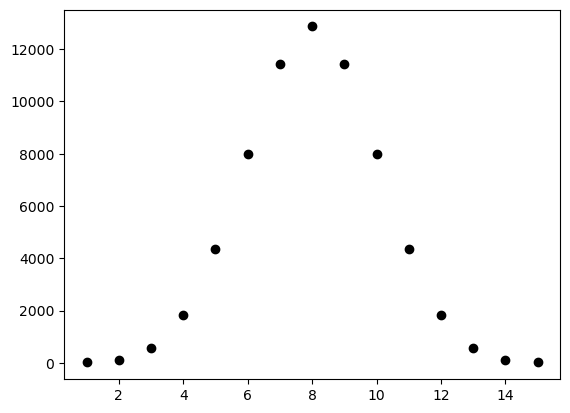

In [137]:
from math import comb
fig, ax = plt.subplots()
num_candidates = 16
for i in range(1,num_candidates):
    combs = comb(num_candidates,i)
    ax.scatter(i,combs,color='k')

In [112]:
total_demand = od_demand['S000'].sum()

def evaluate_configuration(selected_bikeshare, selected_zones, w):
    '''Evaluate the configuration with respect to the objective function. Identify each investment's contribution to the objective to choose next swap.'''
    # Filter the edge cost df to include only the selected investments for this configuration, then load the network with OD demand
    unselected_bikeshare = list(set(bikeshare_candidates) - set(selected_bikeshare))  
    unselected_microtransit = list(set(microtransit_candidates) - set(selected_zones))
    df_edge_cost_investments = remove_unselected_investments(df_edge_cost_sn, df_mt, unselected_microtransit, unselected_bikeshare)   
    network_loading(df_edge_cost_investments, df_node_cost_sn, org_list, dst_list, selected_bikeshare, selected_zones, mt_edge_zone_dict, output_file)

    # Determine decision variables and the objective function
    df_od_cost = pd.read_csv(output_file)
    df_flow = calc_DVs(df_od_cost, Q) 
    system_A_pct, minA_pct, A = calc_objective(df_flow, org_demand, w)  

    # Identify the contributions of each investment to each part of the objective function, along with their combined contribution
    bikeshare_contributions_system, zone_contributions_system = get_system_contributions(df_flow, total_demand, selected_bikeshare, selected_zones)
    minA_org, minA_total_demand, _ = get_minA_org(df_flow, org_demand)
    bikeshare_contributions_minA, zone_contributions_minA = get_min_org_contributions(df_flow, minA_org, minA_total_demand, selected_bikeshare, selected_zones)
    bikeshare_contributions_combined, zone_contributions_combined = get_combined_contributions(bikeshare_contributions_system, bikeshare_contributions_minA, zone_contributions_system, zone_contributions_minA, w)
    
    return system_A_pct, minA_pct, A, bikeshare_contributions_combined, zone_contributions_combined

def get_worst_bikeshare(bikeshare_contributions):
    return bikeshare_contributions[0]

def get_worst_zone(zone_contributions):
    return zone_contributions[0]

# Helper function to determine the worst-performing investment
def get_worst_investment(bikeshare_contributions, zone_contributions):
    worst_bikeshare = get_worst_bikeshare(bikeshare_contributions)
    worst_zone = get_worst_zone(zone_contributions)
    if worst_bikeshare[1] < worst_zone[1]:
        return "bikeshare", worst_bikeshare
    else:
        return "zone", worst_zone

In [147]:
random.seed(1)
# Initialize
num_bikeshare = 6
num_microtransit = 1

# Choose weighting for objective function
w = 0.7

# Randomly select initial candidates
selected_bikeshare = random.sample(bikeshare_candidates, num_bikeshare)
selected_zones = random.sample(microtransit_candidates, num_microtransit)

best_accessibility = float('-inf')  # Best accessibility score
best_combination = (selected_bikeshare, selected_zones)

# Network parameters
# -- Test with fewer OD pairs to start
k = 1
org_list = sorted(set([n for n in G_sn.graph.nodes if n.startswith('org')]))[::k]
dst_list = sorted(set([n for n in G_sn.graph.nodes if n.startswith('dst')]))[::k]
output_file = "od_cost_matrix_results.csv"

# Evaluate the initial configuration
system_A_pct, minA_pct, A, bikeshare_contributions, zone_contributions = evaluate_configuration(selected_bikeshare, selected_zones, w)

evaluated_combinations = [set(selected_bikeshare + selected_zones)]
overall_improved = True  # Track overall improvements across iterations
consecutive_non_improvements = 0  # Track consecutive non-improvements

# Helper function to attempt a swap and evaluate the improvement
def try_swap(selected_list, worst_investment, swap_in_candidates, current_best_accessibility, evaluated_combinations, swap_type):
    best_swap_improvement = 0
    best_swap_in = None

    print('swap in candidates:', swap_in_candidates)
    for swap_in in swap_in_candidates:
        temp_selected = selected_list[:]
        temp_selected.remove(worst_investment)
        temp_selected.append(swap_in)

        current_combination = set(temp_selected + selected_zones if swap_type == 'bikeshare' else temp_selected + selected_bikeshare)
        if current_combination in evaluated_combinations:
            print('current combination already evaluated. skipping.')
            continue
        evaluated_combinations.append(current_combination)

        # Evaluate new configuration
        _, _, A_new, _, _ = evaluate_configuration(
            temp_selected if swap_type == "bikeshare" else selected_bikeshare,
            temp_selected if swap_type == "zone" else selected_zones,
            w
        )
        improvement = A_new - current_best_accessibility
        if improvement > best_swap_improvement:
            best_swap_improvement = improvement
            best_swap_in = swap_in
        print('try swap:', swap_in, 'improvement:', np.round(improvement,4), 'best improvement:', np.round(best_swap_improvement,4))

    return best_swap_improvement, best_swap_in, evaluated_combinations

system_A_pct_tracker = []
minA_pct_tracker = []
A_tracker = []

# Greedy hill climbing
while True:
    # Evaluate current configuration
    print('Selected investments:', selected_bikeshare, selected_zones)
    system_A_pct, minA_pct, A, bikeshare_contributions, zone_contributions = evaluate_configuration(selected_bikeshare, selected_zones, w)
    
    # Keep track of changes over iterations
    system_A_pct_tracker.append(system_A_pct)
    minA_pct_tracker.append(minA_pct)
    A_tracker.append(A)

    if A > best_accessibility:
        best_accessibility = A
        best_combination = (selected_bikeshare, selected_zones)

    # Identify the worst-performing investment
    swap_type, worst_investment = get_worst_investment(bikeshare_contributions, zone_contributions)
    print('worst performer:', swap_type, worst_investment)
    unselected_candidates = (list(set(bikeshare_candidates) - set(selected_bikeshare)) if swap_type == "bikeshare" else list(set(microtransit_candidates) - set(selected_zones)))
    selected_list = selected_bikeshare if swap_type == "bikeshare" else selected_zones
    improvement, best_swap_in, evaluated_combinations = try_swap(selected_list, worst_investment[0], unselected_candidates, best_accessibility, evaluated_combinations, swap_type)

    if improvement > 0:
        # Apply the best swap
        selected_list.remove(worst_investment[0])
        print('best swap', best_swap_in)
        selected_list.append(best_swap_in)

        # Reflect changes in the correct list
        if swap_type == "bikeshare":
            selected_bikeshare = selected_list
        else:
            selected_zones = selected_list

        consecutive_non_improvements = 0  # Reset non-improvement counter

    else:
        print('no improvement. trying other type')
        consecutive_non_improvements += 1
        # Try swapping the other type
        swap_type = "zone" if swap_type == "bikeshare" else "bikeshare"
        worst_investment = get_worst_bikeshare(bikeshare_contributions) if swap_type == "bikeshare" else get_worst_zone(zone_contributions)
        print('worst performer:', swap_type, worst_investment)
        unselected_candidates = (list(set(bikeshare_candidates) - set(selected_bikeshare)) if swap_type == "bikeshare" else list(set(microtransit_candidates) - set(selected_zones)))
        selected_list = selected_bikeshare if swap_type == "bikeshare" else selected_zones
        improvement, best_swap_in, evaluated_combinations = try_swap(selected_list, worst_investment[0], unselected_candidates, best_accessibility, evaluated_combinations, swap_type)
        print('best swap', best_swap_in)

        if improvement > 0:
            # Apply the best swap
            selected_list.remove(worst_investment[0])
            selected_list.append(best_swap_in)
            # Reflect changes in the correct list
            if swap_type == "bikeshare":
                selected_bikeshare = selected_list
            else:
                selected_zones = selected_list
            consecutive_non_improvements = 0  # Reset non-improvement counter
        else:
            consecutive_non_improvements += 1

    # Stop if no improvements are found
    if consecutive_non_improvements >= 2:
        print("No further improvements found. Stopping.")
        break

print("Best combination:", best_combination)
print("Best accessibility score:", best_accessibility)

Selected investments: ['bsd12', 'bsd10', 'bsd16', 'bsd1', 'bsd15', 'bsd4'] [3]
worst performer: bikeshare ('bsd15', 0.0224)
swap in candidates: ['bsd6', 'bsd7', 'bsd11', 'bsd13', 'bsd2', 'bsd8', 'bsd3', 'bsd0', 'bsd14', 'bsd5', 'bsd17', 'bsd9']
try swap: bsd6 improvement: 0.0007 best improvement: 0.0007
try swap: bsd7 improvement: 0.0 best improvement: 0.0007
try swap: bsd11 improvement: -0.0007 best improvement: 0.0007
try swap: bsd13 improvement: -0.0014 best improvement: 0.0007
try swap: bsd2 improvement: 0.0 best improvement: 0.0007
try swap: bsd8 improvement: 0.0 best improvement: 0.0007
try swap: bsd3 improvement: -0.0014 best improvement: 0.0007
try swap: bsd0 improvement: -0.0014 best improvement: 0.0007
try swap: bsd14 improvement: -0.0007 best improvement: 0.0007
try swap: bsd5 improvement: 0.0057 best improvement: 0.0057
try swap: bsd17 improvement: 0.0074 best improvement: 0.0074
try swap: bsd9 improvement: -0.0007 best improvement: 0.0074
best swap bsd17
Selected investmen

In [148]:
system_A_pct_tracker, minA_pct_tracker, A_tracker

([0.613, 0.612, 0.618], [0.407, 0.434, 0.445], [0.5512, 0.5586, 0.5661])

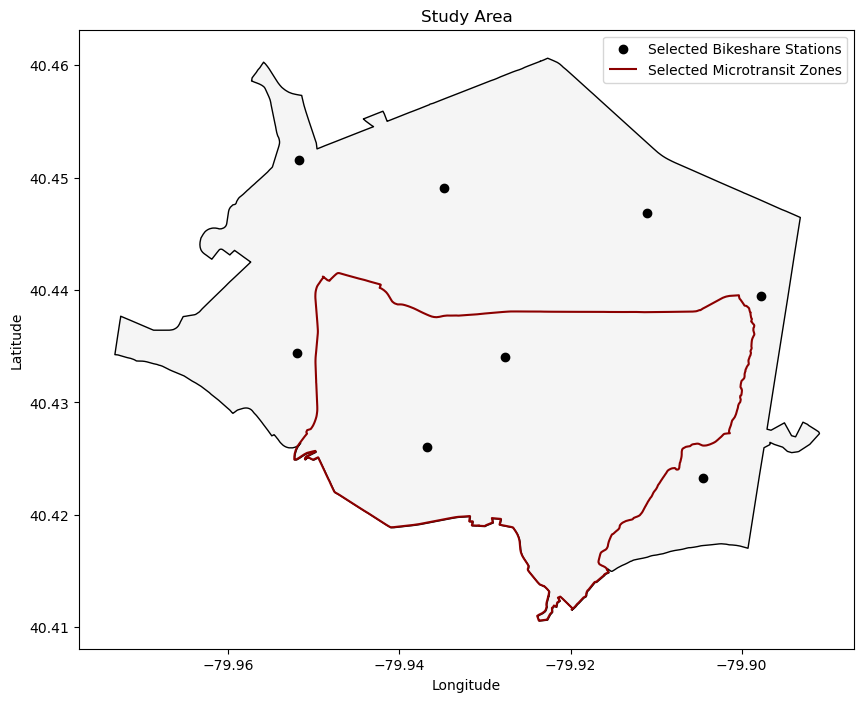

In [146]:
from shapely import wkt
import re 

def extract_numbers(strings):
    all_numbers = []
    for string in strings:
        numbers = re.findall(r'\d+', string)
        all_numbers.extend(numbers)
    return [int(num) for num in all_numbers]

neighborhoods_gdf = gpd.read_file(config['paths']['data']['neighborhoods_in'])
hoods_keep_gdf = neighborhoods_gdf[neighborhoods_gdf['hood'].isin(config['geography']['neighborhoods'])]

bikeshare_df = pd.read_csv(config['paths']['data']['bikeshare_station'])
bikeshare_df['geometry'] = bikeshare_df['geometry'].apply(wkt.loads)
bikeshare_gdf = gpd.GeoDataFrame(bikeshare_df, geometry='geometry', crs=neighborhoods_gdf.crs)
bikeshare_best = extract_numbers(best_combination[0])

microtransit_gdf = gpd.read_file(config['paths']['data']['microtransit_zones']).to_crs(neighborhoods_gdf.crs)
microtransit_best = best_combination[1]

# Plot the GeoDataFrame
fig, ax = plt.subplots(figsize=(10, 10))
hoods_keep_gdf.dissolve().plot(ax=ax, color='whitesmoke', edgecolor='black').plot(ax=ax, color='lightblue', edgecolor='black', label='Study Area')
bikeshare_gdf[bikeshare_gdf['id'].isin(bikeshare_best)].plot(ax=ax, color='black', label='Selected Bikeshare Stations')
microtransit_gdf[microtransit_gdf['id'].isin(microtransit_best)].boundary.plot(ax=ax, edgecolor='darkred', label='Selected Microtransit Zones')
plt.legend()
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Study Area')
plt.show()

/home/lgraff/ENTER/envs/py39/lib/python3.9/site-packages/geopandas/tools/clip.py:67: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  clipped.loc[


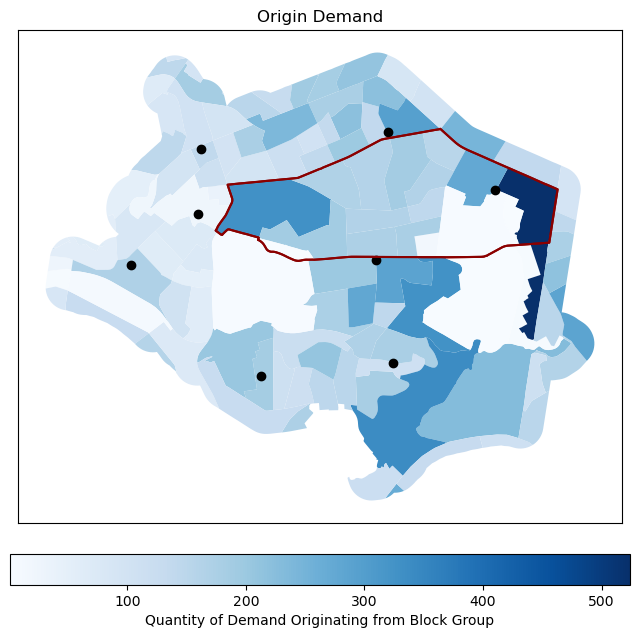

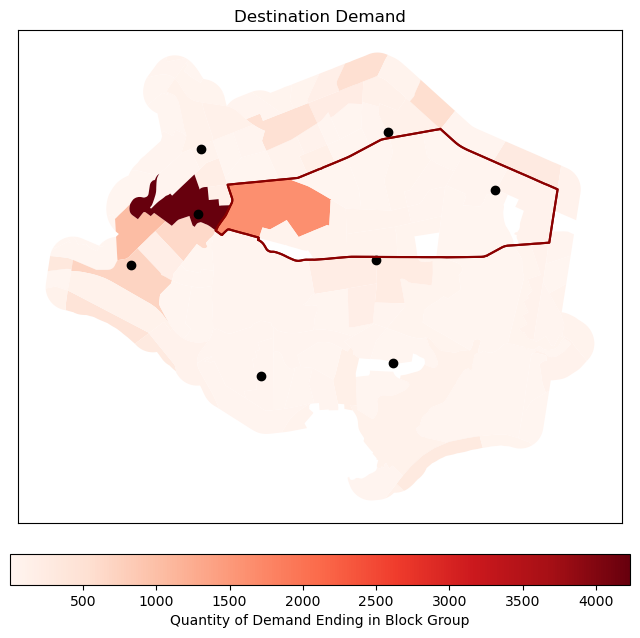

In [96]:
study_area_gdf = gpd.read_file(config['paths']['data']['study_area_out'])
study_area_gdf.to_crs(epsg=4269, inplace=True)

shapefile_path = Path().resolve() / 'data' / 'demographics' / 'raw' / 'tl_2022_42_bg' / 'tl_2022_42_bg.shp'
shape = gpd.read_file(shapefile_path, mask=study_area_gdf)  # only include blocks within study area
shape.to_crs(epsg=4269, inplace=True)
shape = gpd.clip(shape, study_area_gdf) # clip again
shape.to_crs(epsg=4326, inplace=True)

org_demand = od_demand.groupby('h_geocode_blockgroup')['S000'].sum().reset_index().rename(columns={'h_geocode_blockgroup':'GEOID'})
dst_demand = od_demand.groupby('w_geocode_blockgroup')['S000'].sum().reset_index().rename(columns={'w_geocode_blockgroup':'GEOID'})

org_demand['GEOID'] = org_demand['GEOID'].astype(str)
dst_demand['GEOID'] = dst_demand['GEOID'].astype(str)
org_demand_gdf = shape.merge(org_demand, how='right', on='GEOID')
dst_demand_gdf = shape.merge(dst_demand, how='right', on='GEOID')

# Plot the origin demand GeoDataFrame
fig, ax = plt.subplots(figsize=(8, 8))
org_demand_gdf.plot(column='S000', legend=True, cmap='Blues', legend_kwds={'label': 'Quantity of Demand Originating from Block Group', 'orientation':'horizontal', 'pad':0.05}, ax=ax)
bikeshare_gdf[bikeshare_gdf['id'].isin(bikeshare_best)].plot(ax=ax, color='black', label='Selected Bikeshare Stations')
microtransit_gdf[microtransit_gdf['id'].isin(microtransit_best)].boundary.plot(ax=ax, edgecolor='darkred', label='Selected Microtransit Zones')
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
plt.title('Origin Demand')
plt.show()

# Plot the destination demand GeoDataFrame
fig, ax = plt.subplots(figsize=(8, 8))
dst_demand_gdf.plot(column='S000', legend=True, cmap='Reds', legend_kwds={'label': 'Quantity of Demand Ending in Block Group', 'orientation':'horizontal', 'pad':0.05}, ax=ax)
bikeshare_gdf[bikeshare_gdf['id'].isin(bikeshare_best)].plot(ax=ax, color='black', label='Selected Bikeshare Stations')
microtransit_gdf[microtransit_gdf['id'].isin(microtransit_best)].boundary.plot(ax=ax, edgecolor='darkred', label='Selected Microtransit Zones')
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
plt.title('Destination Demand')
plt.show()

In [93]:
org_demand_gdf.head()

,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,GEOID,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,42,003,010301,1,420030103011,Block Group 1,G5030,S,276652,217524,+40.4340503,-079.9864299,"POLYGON ((-79.97601 40.43637, -79.97557 40.436..."
1,42,003,010302,2,420030103022,Block Group 2,G5030,S,312028,0,+40.4370530,-079.9808185,"POLYGON ((-79.97622 40.43816, -79.97589 40.438..."
2,42,003,030500,2,420030305002,Block Group 2,G5030,S,280636,0,+40.4403910,-079.9813877,"POLYGON ((-79.97572 40.43921, -79.97537 40.439..."
3,42,003,040200,1,420030402001,Block Group 1,G5030,S,322183,0,+40.4381815,-079.9683880,"MULTIPOLYGON (((-79.97590 40.43900, -79.97537 ..."
4,42,003,040200,2,420030402002,Block Group 2,G5030,S,282677,0,+40.4412437,-079.9626108,"POLYGON ((-79.96548 40.44302, -79.96518 40.443..."


In [90]:
shape.dtypes

STATEFP       object
COUNTYFP      object
TRACTCE       object
BLKGRPCE      object
GEOID         object
NAMELSAD      object
MTFCC         object
FUNCSTAT      object
ALAND          int64
AWATER         int64
INTPTLAT      object
INTPTLON      object
geometry    geometry
dtype: object

In [86]:
microtransit_gdf

,id,geometry
0,0,"POLYGON ((-79.94978 40.43420, -79.94979 40.434..."
1,1,"POLYGON ((-79.91321 40.43803, -79.91326 40.438..."
2,2,"POLYGON ((-79.89192 40.42644, -79.89209 40.426..."
3,3,"POLYGON ((-79.92692 40.41890, -79.92751 40.418..."
4,4,"POLYGON ((-79.94978 40.43420, -79.94979 40.434..."
5,5,"POLYGON ((-79.94727 40.44703, -79.94716 40.446..."
6,6,"POLYGON ((-79.91321 40.43803, -79.91326 40.438..."


In [22]:
# import random
# import pandas as pd

# random.seed(0)

# # Initialize parameters
# num_bikeshare = 6
# num_microtransit = 2

# # Randomly select initial candidates
# selected_bikeshare = random.sample(bikeshare_candidates, num_bikeshare)
# selected_microtransit_zoneID = random.sample(microtransit_candidates, num_microtransit)

# # Unselected candidates
# unselected_bikeshare = list(set(bikeshare_candidates) - set(selected_bikeshare))
# unselected_microtransit_zoneID = list(set(microtransit_candidates) - set(selected_microtransit_zoneID))

# best_accessibility = float('-inf')  # Best accessibility score
# best_combination = (selected_bikeshare, selected_microtransit_zoneID)

# # Network parameters
# # -- Test with fewer OD pairs to start
# k = 5
# org_list = sorted(set([n for n in G_sn.graph.nodes if n.startswith('org')]))[::k]
# dst_list = sorted(set([n for n in G_sn.graph.nodes if n.startswith('dst')]))[::k]
# output_file = "od_cost_matrix_results.csv"

# evaluated_combinations = []

# overall_improved = True  # Track overall improvements across iterations

# while overall_improved:
#     overall_improved = False  # Reset the improvement flag for this iteration
#     print('starting while loop with', sorted(selected_bikeshare))

#     for swap_out in selected_bikeshare:
#         # Iterate over each selected bikeshare station
#         improvement_found = False  # Flag to indicate if an improvement is found
#         print('swapout', swap_out)
        
#         for swap_in in unselected_bikeshare:  
            
#             # Create a temporary list for the new selection
#             temp_bikeshare = selected_bikeshare[:]
#             temp_bikeshare.remove(swap_out)
#             temp_bikeshare.append(swap_in)
#             print(sorted(temp_bikeshare))

#             current_combination = set(temp_bikeshare + selected_microtransit_zoneID)

#             # Skip if the combination has already been evaluated
#             if current_combination in evaluated_combinations:
#                 continue

#             # Add to the set of evaluated combinations
#             evaluated_combinations.append(current_combination)

#             # Evaluate the new configuration
#             unselected_bikeshare_temp = list(set(bikeshare_candidates) - set(temp_bikeshare))   
#             df_edge_cost_investments = remove_unselected_investments(df_edge_cost_sn, df_mt, unselected_microtransit_zoneID, unselected_bikeshare_temp)   
#             network_loading(df_edge_cost_investments, df_node_cost_sn, org_list, dst_list, output_file) 
#             df_od_cost = pd.read_csv(output_file)
#             df_flow = calc_DVs(df_od_cost, Q) 
#             A = calc_objective(df_flow)   

#             # Check for improvement
#             if A > best_accessibility:
#                 # Update the best configuration
#                 best_accessibility = A
#                 best_combination = (temp_bikeshare[:], selected_microtransit[:])
#                 # Update the selected and unselected investments
#                 selected_bikeshare = temp_bikeshare[:]
#                 unselected_bikeshare = list(set(bikeshare_candidates) - set(selected_bikeshare))
#                 print(f"New best accessibility found: {best_accessibility} with {sorted(temp_bikeshare)}")

#                 overall_improved = True
#                 improvement_found = True
#                 break
        
#         if improvement_found:
#             break 

#     print('Overall improved?', overall_improved)
    
#     if not overall_improved:
#         print("No improvement found for any bikeshare swap. Stopping optimization.")
#         break

starting while loop with ['bsd0', 'bsd12', 'bsd15', 'bsd16', 'bsd4', 'bsd5']
swapout bsd4
['bsd0', 'bsd11', 'bsd12', 'bsd15', 'bsd16', 'bsd5']
New best accessibility found: 298.142693010107 with ['bsd0', 'bsd11', 'bsd12', 'bsd15', 'bsd16', 'bsd5']
Overall improved? True
starting while loop with ['bsd0', 'bsd11', 'bsd12', 'bsd15', 'bsd16', 'bsd5']
swapout bsd5
['bsd0', 'bsd11', 'bsd12', 'bsd15', 'bsd16', 'bsd7']
New best accessibility found: 298.3979868014324 with ['bsd0', 'bsd11', 'bsd12', 'bsd15', 'bsd16', 'bsd7']
Overall improved? True
starting while loop with ['bsd0', 'bsd11', 'bsd12', 'bsd15', 'bsd16', 'bsd7']
swapout bsd0
['bsd11', 'bsd12', 'bsd15', 'bsd16', 'bsd5', 'bsd7']
New best accessibility found: 298.4382791017622 with ['bsd11', 'bsd12', 'bsd15', 'bsd16', 'bsd5', 'bsd7']
Overall improved? True
starting while loop with ['bsd11', 'bsd12', 'bsd15', 'bsd16', 'bsd5', 'bsd7']
swapout bsd12
['bsd11', 'bsd15', 'bsd16', 'bsd5', 'bsd7', 'bsd9']
['bsd11', 'bsd15', 'bsd16', 'bsd2', 'bs

In [ ]:
# Multistart hill climbing
global_best_accessibility = float('-inf')
global_best_combination = None

for start in range(num_starts):
    print(f"Starting iteration {start + 1} of {num_starts}")
    best_accessibility, best_combination = hill_climbing()
    if best_accessibility > global_best_accessibility:
        global_best_accessibility = best_accessibility
        global_best_combination = best_combination

print(f"Global best accessibility: {global_best_accessibility}")
print(f"Global best combination: {global_best_combination}")